In [511]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import random

In [512]:
def generate_data(true_func, n_sample, x_range, noise_std, random_x):
    y = []

    if random_x:
        x = np.random.uniform(x_range[0], x_range[1], n_sample)
    else:
        x = np.linspace(x_range[0], x_range[1], n_sample)

    for idx, item in enumerate(x):
        if noise_std > 0:
            y.append(true_func(item)+ random.random())
        else:
            y.append(true_func(item))

    return x, np.array(y)



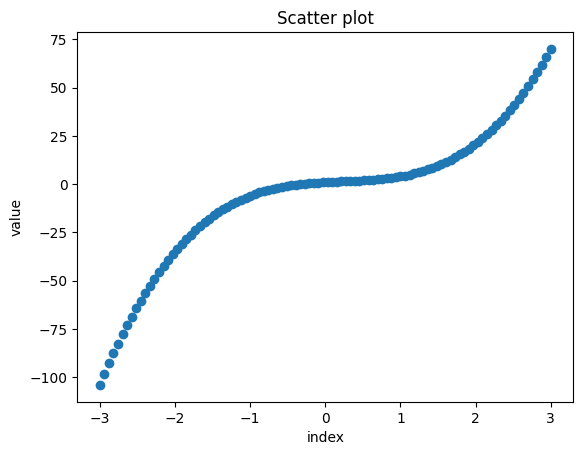

In [513]:
x_test, y_test = generate_data(lambda x: ((x**3) * 3) + ((x**2) * -2) + (x * 2) + 1, 100, (-3, 3), 0, False)
plt.scatter(x_test, y_test)
plt.xlabel("index")
plt.ylabel("value")
plt.title("Scatter plot")
plt.show()

In [514]:
degrees = [1, 2, 3, 4, 5, 6]
predicted_value = {}

for degree in degrees:
    degree_predicted_value = []
    for i in range(50):
        train_x, train_y = generate_data(lambda x: ((x**3) * 3) + ((x**2) * -2) + (x * 2) + 1, 100, (-3, 3), 1, True)
        train_x = train_x.reshape(-1, 1)

        poly = PolynomialFeatures(degree=degree, include_bias=False)
        train_x_ready = poly.fit_transform(train_x)

        lr = LinearRegression()
        lr.fit(train_x_ready, train_y)

        #print(f"Original X_train shape: {train_x.shape}")
        #print(f"Polynomial X_train shape (degree {degree}): {train_x_ready.shape}")

        y_predict = lr.predict(poly.transform(x_test.reshape(-1, 1)))
        degree_predicted_value.append(y_predict)

        model_score = lr.score(poly.transform(x_test.reshape(-1, 1)), y_test)

    predicted_value[f'degree_{degree}'] = np.array(degree_predicted_value)



In [515]:
means = predicted_value['degree_1'].mean(axis=0)
mean_dict = {}
variance_dict = {}
for key in predicted_value:
    mean = predicted_value[key].mean(axis=0)
    variance = predicted_value[key].var(axis=0)
    mean_dict[f'mean_{key}'] = mean
    variance_dict[f'variance_{key}'] = variance

In [516]:
bias_dict = {}
i = 0
for key in mean_dict:
    bias_arr = []
    for idx, item in enumerate(mean_dict[key]):
        bias = item - y_test[idx]
        bias_arr.append(bias)
    i = i + 1
    bias_dict[f'bias_degree_{i}'] = bias_arr

In [517]:
err_dict = {}
i = 0
for (k1, v), (k2, b) in zip(variance_dict.items(), bias_dict.items()):
    err_arr = []
    for variance,bias in zip(v, b):
        err = bias ** 2 + variance
        err_arr.append(err)
    i = i + 1
    err_dict[f'err_degree_{i}'] = err_arr

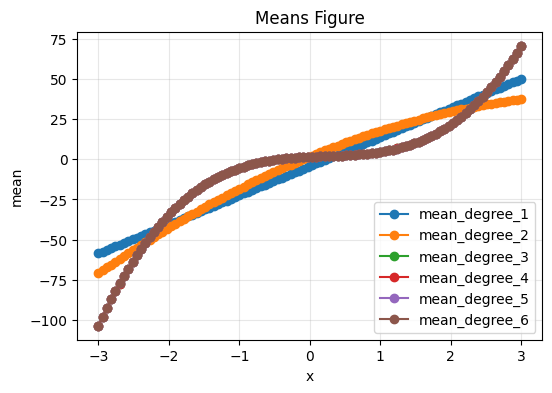

In [518]:
plt.figure(figsize=(6,4))

for k, y in mean_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('mean')
plt.title('Means Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

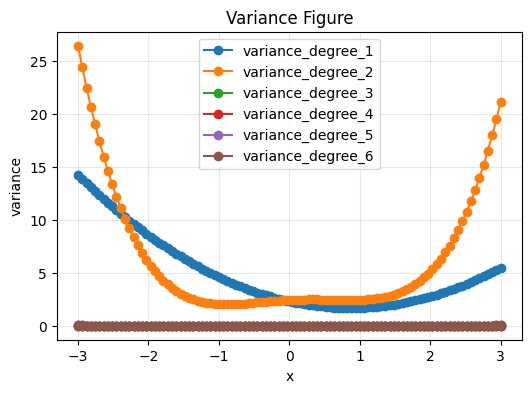

In [519]:
plt.figure(figsize=(6,4))

for k, y in variance_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('variance')
plt.title('Variance Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

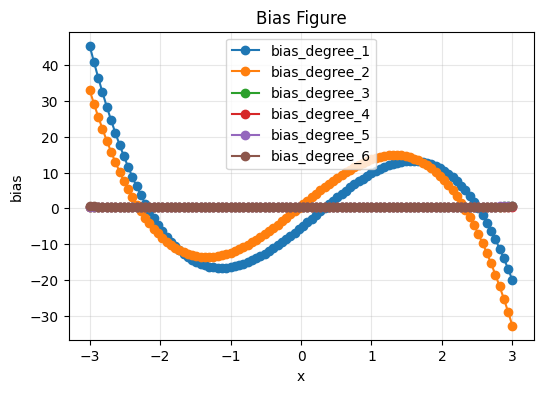

In [520]:
plt.figure(figsize=(6,4))

for k, y in bias_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('bias')
plt.title('Bias Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

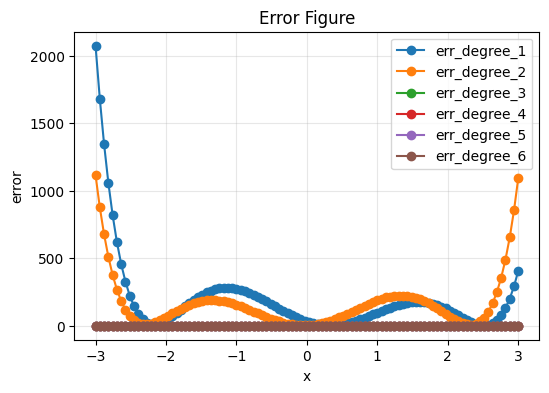

In [521]:
plt.figure(figsize=(6,4))

for k, y in err_dict.items():
    plt.plot(x_test, y, marker='o', label=k)

plt.xlabel('x')
plt.ylabel('error')
plt.title('Error Figure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

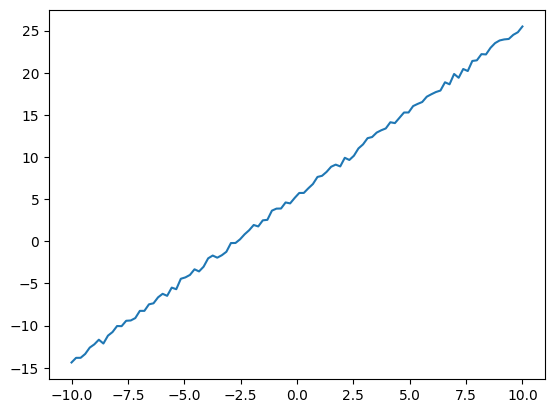

In [522]:
data_number = 100
x_data, y_data = generate_data(lambda x: 2*x+5, data_number, (-10, 10), 1, random_x=False)

plt.plot(x_data, y_data)
plt.show()

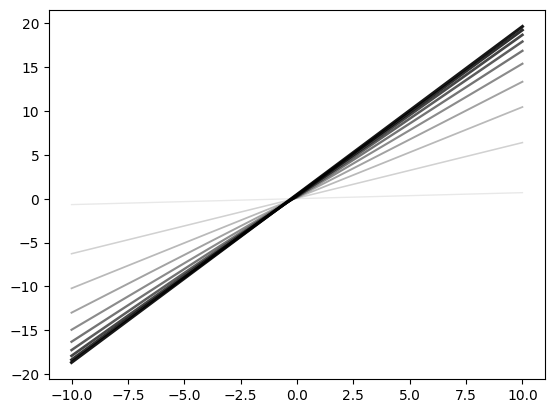

In [523]:
w0 , w1 = 0, 0
w0_arr , w1_arr, jw_arr = [w0], [w1], [jw()]
n = 0.001


def hw(x):
    return w0 + w1 * x


def gradian(x):
    sum_data = 0
    for idx, item in enumerate(x_data):
        if x == 'w0':
            sum_data = sum_data + (hw(item) - y_data[idx])
        else:
            sum_data = sum_data + ((hw(item) - y_data[idx]) * item)
    return(1/data_number) * sum_data


def jw():
    sum_data = 0
    for idx, item in enumerate(x_data):
        sum_data = sum_data + ((hw(item) - y_data[idx]) ** 2)

    return(1/data_number) * sum_data

fig, ax = plt.subplots()

for i in range(100):
    w0 = w0 - (n * gradian('w0'))
    w1 = w1 - (n * gradian('w1'))
    
    jw_arr.append(jw())
    w0_arr.append(w0) 
    w1_arr.append(w1) 

    y_trained_arr = []
    for data in x_data:
        y_trained_arr.append(w0 + w1 * data)

    alpha = (i + 10) / 110
    linewidth = 1 + (i / 150) * 2

    if i % 10 == 0:
        ax.plot(x_data, y_trained_arr, color='black', alpha=alpha, linewidth=linewidth, label=f'Line {i+1}')

plt.show()


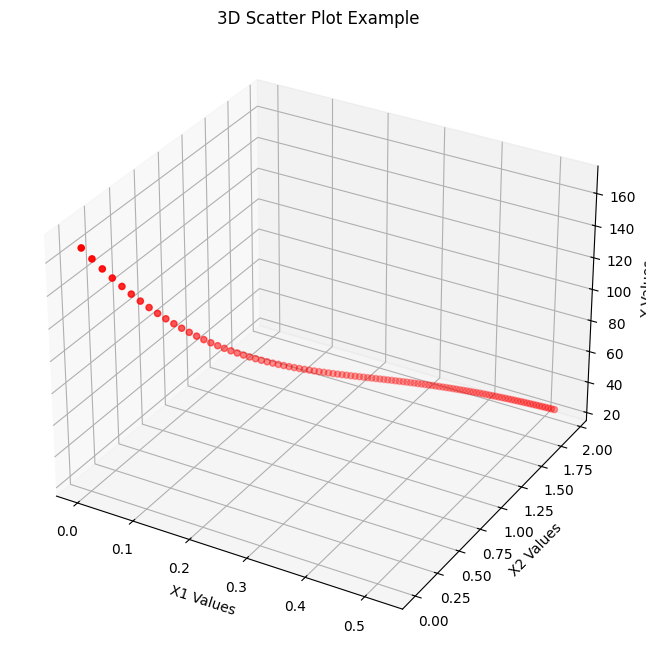

In [524]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(w0_arr, w1_arr, jw_arr, c='r', marker='o')

# Set labels for the axes
ax.set_xlabel('X1 Values')
ax.set_ylabel('X2 Values')
ax.set_zlabel('Y Values')

plt.title('3D Scatter Plot Example')
plt.show()

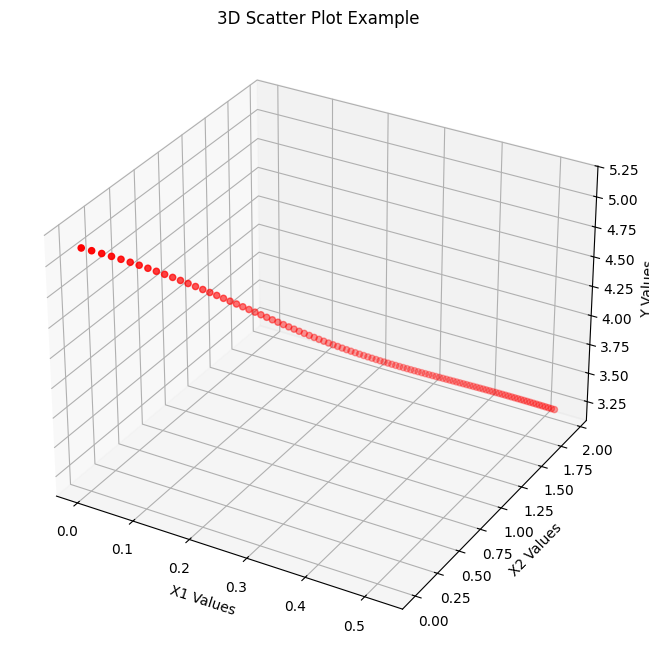

In [525]:
natural_log_a = np.log(jw_arr)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(w0_arr, w1_arr, natural_log_a, c='r', marker='o')

# Set labels for the axes
ax.set_xlabel('X1 Values')
ax.set_ylabel('X2 Values')
ax.set_zlabel('Y Values')

plt.title('3D Scatter Plot Example')
plt.show()